# Declaración responsable sobre autoría y uso ético de inteligencia artificial, otros recursos o ayuda externa

Con la entrega de esta tarea, declaro de manera responsable que
es el resultado de mi trabajo intelectual personal y creativo, y que ha sido elaborado de acuerdo con los principios éticos y las normas de integridad vigentes en la comunidad académica y, más
específicamente, en la [Universidad Complutense de Madrid](https://www.ucm.es/file/declaracion-responsable-sobre-autoria-y-uso-%C3%89tico-de-herramientas-de-ia).

Soy, pues, autor del material aquí incluido y, cuando no ha sido así y he tomado el material de
otra fuente, lo he citado o bien he declarado su procedencia de forma clara -incluidas, en su
caso, herramientas de inteligencia artificial-. Las ideas y aportaciones principales incluidas en este trabajo, y que acreditan la adquisición de competencias, son mías y no proceden de otras fuentes o han sido reescritas usando material de otras fuentes.

Antes de entregar esta tarea, asegúrate de que todo funcione como se espera:

1. Reinicia el kernel  
   *(En la barra de menú, selecciona **Kernel → Restart**)*  

2. Ejecuta todas las celdas  
   *(En la barra de menú, selecciona **Cell → Run All**)*  

3. Asegúrate de completar todos los lugares donde aparezca:  
   - `YOUR CODE HERE`  
   - `"YOUR ANSWER HERE"`
     
4. Debes borrar las instrucciones que pone `raise NotImplementedError()`

5. Así como tu **nombre** a continuación:

In [1]:
NOMBRE = "Carlos San Román Cazorla"

## Notas para la entrega

* Se deben rellenar todos los cuadernos sin cambiar el nombre.
* Se debe comprimir la carpeta en un fichero `.zip`, llamado `tarea_final.zip`. **Importante**: por favor, no se entreguen ficheros `.rar`.
* Subir el fichero comprimido al campus virtual.

In [2]:
# En esta casilla pon los import que necesites en este cuaderno.

import testing
# YOUR CODE HERE
import pandas as pd
import matplotlib.pyplot as plt

# Si línea da error, debería actualizar a una versión más reciente de Python.
type DataFrame = pd.core.frame.DataFrame


# Operaciones con dataframes

En este apartado, vamos a trabajar con tablas de la librería `pandas`, llamadas `dataframes`.

## Carga del dataframe

La primera operación que necesitamos es cargar el archivo de datos en una tabla, como se ve en el siguiente ejemplo.
Ten en cuenta que las columnas `FX_DATA` y `FECHA_INSCRIPCION` deben contener elementos de tipo fecha.
La fecha en la columna `FX_DATA` no presenta mayo complicación, basta con indicarlo en el parámetro 
`parse_dates` de la función que lee el csv. 

Pero como vimos, el paso a fecha de la columna `FECHA_INSCRIPCION` no funciona en algunos sistemas.
Lo que vamos a hacer es tener dos columnas nuevas llamadas `MES_INSCRIPCION` y `ANYO_INSCRIPCION` (en ese orden) de forma que la primera contenga el mes como una cadena de caracteres y la segunda el día como un entero. 

Un último detalle. Si visualizas el CSV (siguiente casilla), podrás observar que la descripción del distrito tiene un espacio adicional que hay que quitar.

In [3]:
with open('inscritos.csv') as fl:
    for _ in range(5):
        print(fl.readline().strip())

FECHA_INSCRIPCION;GENERO_DESC;DISTRITO_COD;DISTRITO_DESC;EDAD;NACIONALIDAD_DESC;OBJETIVOPROFESIONAL1_COD;OBJETIVOPROFESIONAL1_DESC;OBJETIVOPROFESIONAL2_COD;OBJETIVOPROFESIONAL2_DESC;OBJETIVOPROFESIONAL3_COD;OBJETIVOPROFESIONAL3_DESC;FX_CARGA
"ene-24";"Hombre";10;" LATINA";34;"Español";"5833";"Conserjes de edificios";"5220";"Vendedores en tiendas y almacenes";"9602";"Peones de la construcción de edificios";"2025-08-07 00:11:57.897"
"ene-20";"Hombre";10;" LATINA";40;"Extracomunitario";"5500";"Cajeros y taquilleros (excepto bancos)";"5220";"Vendedores en tiendas y almacenes";"9602";"Peones de la construcción de edificios";"2025-08-07 00:11:57.897"
"nov-23";"Hombre";13;" PUENTE DE VALLECAS";24;"Extracomunitario";"3510";"Agentes y representantes comerciales";"5420";"Operadores de telemarketing";"9602";"Peones de la construcción de edificios";"2025-08-07 00:11:57.897"
"oct-23";"Hombre";17;" VILLAVERDE";19;"Extracomunitario";"9820";"Reponedores";"5220";"Vendedores en tiendas y almacenes";"960

In [4]:
def load_dataframe(archivo: str) -> DataFrame:
    """
    Lee el archivo csv pasado como argumento y lo pasa a una dataframe de pandas.

    Parametros:
    -----------
    archivo : str. Ruta al archivo csv que se desea cargar.

    Returns:
    --------
    DataFrame : DataFrame de pandas con los datos del archivo csv
    con los datos almacenados como los pide el enunciado

    Example:
    --------
    >>> import pandas as pd
    >>> df = load_dataframe('inscritos.csv')
    """
    df = pd.read_csv(archivo, sep=";", parse_dates=['FX_CARGA'])
    
    # Limpiamos espacios en blanco en todas las columnas de texto
    df = df.apply(lambda x: x.str.strip() if x.dtype == "string" else x)
    
    # Operamos las fechas para obtener el formato de tabla pedido
    df['MES_INSCRIPCION'] = df['FECHA_INSCRIPCION'].str[:3]
    df['ANYO_INSCRIPCION'] = df['FECHA_INSCRIPCION'].str[4:].astype(int)
    
    return df

In [5]:
# Casilla para hacer pruebas

data = load_dataframe("inscritos_test_sample.csv")
str(data['ANYO_INSCRIPCION'].dtype)
data.head()


,FECHA_INSCRIPCION,GENERO_DESC,DISTRITO_COD,DISTRITO_DESC,EDAD,NACIONALIDAD_DESC,OBJETIVOPROFESIONAL1_COD,OBJETIVOPROFESIONAL1_DESC,OBJETIVOPROFESIONAL2_COD,OBJETIVOPROFESIONAL2_DESC,OBJETIVOPROFESIONAL3_COD,OBJETIVOPROFESIONAL3_DESC,FX_CARGA,MES_INSCRIPCION,ANYO_INSCRIPCION
0,jun-17,Hombre,22,OTRO MUNICIPIO,28.0,Español,9229.0,Otro personal de limpieza,9820.0,Reponedores,5220.0,Vendedores en tiendas y almacenes,2025-08-07 00:11:57.897,jun,17
1,may-23,Hombre,14,MORATALAZ,51.0,Español,3123.0,Técnicos en electricidad,7510.0,Electricistas de la construcción y afines,9602.0,Peones de la construcción de edificios,2025-08-07 00:11:57.897,may,23
2,jul-23,Hombre,13,PUENTE DE VALLECAS,49.0,Extracomunitario,9811.0,Peones del transporte de mercancías y descarga...,7240.0,"Soladores, colocadores de parquet y afines",9602.0,Peones de la construcción de edificios,2025-08-07 00:11:57.897,jul,23
3,may-23,Mujer,12,USERA,41.0,Extracomunitario,5710.0,Trabajadores de los cuidados personales a domi...,9210.0,"Personal de limpieza de oficinas, hoteles y ot...",9700.0,Peones de las industrias manufactureras,2025-08-07 00:11:57.897,may,23
4,ene-23,Mujer,22,OTRO MUNICIPIO,43.0,Extracomunitario,9310.0,Ayudantes de cocina,7835.0,"Tapiceros, colchoneros y afines",9700.0,Peones de las industrias manufactureras,2025-08-07 00:11:57.897,ene,23


### Auto-comprobación

In [6]:
# Prueba:

full_data = load_dataframe("inscritos.csv")

print(full_data.dtypes)
full_data

FECHA_INSCRIPCION                       str
GENERO_DESC                             str
DISTRITO_COD                          int64
DISTRITO_DESC                           str
EDAD                                  int64
NACIONALIDAD_DESC                       str
OBJETIVOPROFESIONAL1_COD            float64
OBJETIVOPROFESIONAL1_DESC               str
OBJETIVOPROFESIONAL2_COD            float64
OBJETIVOPROFESIONAL2_DESC               str
OBJETIVOPROFESIONAL3_COD            float64
OBJETIVOPROFESIONAL3_DESC               str
FX_CARGA                     datetime64[us]
MES_INSCRIPCION                         str
ANYO_INSCRIPCION                      int64
dtype: object


,FECHA_INSCRIPCION,GENERO_DESC,DISTRITO_COD,DISTRITO_DESC,EDAD,NACIONALIDAD_DESC,OBJETIVOPROFESIONAL1_COD,OBJETIVOPROFESIONAL1_DESC,OBJETIVOPROFESIONAL2_COD,OBJETIVOPROFESIONAL2_DESC,OBJETIVOPROFESIONAL3_COD,OBJETIVOPROFESIONAL3_DESC,FX_CARGA,MES_INSCRIPCION,ANYO_INSCRIPCION
0,ene-24,Hombre,10,LATINA,34,Español,5833.0,Conserjes de edificios,5220.0,Vendedores en tiendas y almacenes,9602.0,Peones de la construcción de edificios,2025-08-07 00:11:57.897,ene,24
1,ene-20,Hombre,10,LATINA,40,Extracomunitario,5500.0,Cajeros y taquilleros (excepto bancos),5220.0,Vendedores en tiendas y almacenes,9602.0,Peones de la construcción de edificios,2025-08-07 00:11:57.897,ene,20
2,nov-23,Hombre,13,PUENTE DE VALLECAS,24,Extracomunitario,3510.0,Agentes y representantes comerciales,5420.0,Operadores de telemarketing,9602.0,Peones de la construcción de edificios,2025-08-07 00:11:57.897,nov,23
3,oct-23,Hombre,17,VILLAVERDE,19,Extracomunitario,9820.0,Reponedores,5220.0,Vendedores en tiendas y almacenes,9602.0,Peones de la construcción de edificios,2025-08-07 00:11:57.897,oct,23
4,may-23,Hombre,17,VILLAVERDE,42,Extracomunitario,9512.0,"Peones agrícolas en huertas, invernaderos, viv...",5220.0,Vendedores en tiendas y almacenes,9602.0,Peones de la construcción de edificios,2025-08-07 00:11:57.897,may,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150132,may-23,Mujer,11,CARABANCHEL,33,Extracomunitario,5500.0,Cajeros y taquilleros (excepto bancos),5420.0,Operadores de telemarketing,9811.0,Peones del transporte de mercancías y descarga...,2025-08-07 00:12:50.377,may,23
150133,mar-19,Mujer,22,OTRO MUNICIPIO,50,Extracomunitario,8193.0,"Operadores de máquinas de embalaje, embotellam...",5220.0,Vendedores en tiendas y almacenes,9811.0,Peones del transporte de mercancías y descarga...,2025-08-07 00:12:50.377,mar,19
150134,may-21,Hombre,17,VILLAVERDE,35,Extracomunitario,8333.0,Operadores de carretillas elevadoras,5942.0,Auxiliares de vigilante de seguridad y similar...,9811.0,Peones del transporte de mercancías y descarga...,2025-08-07 00:12:50.377,may,21
150135,dic-18,Hombre,2,ARGANZUELA,42,Español,9811.0,Peones del transporte de mercancías y descarga...,5942.0,Auxiliares de vigilante de seguridad y similar...,9811.0,Peones del transporte de mercancías y descarga...,2025-08-07 00:12:50.377,dic,18


Salida esperada

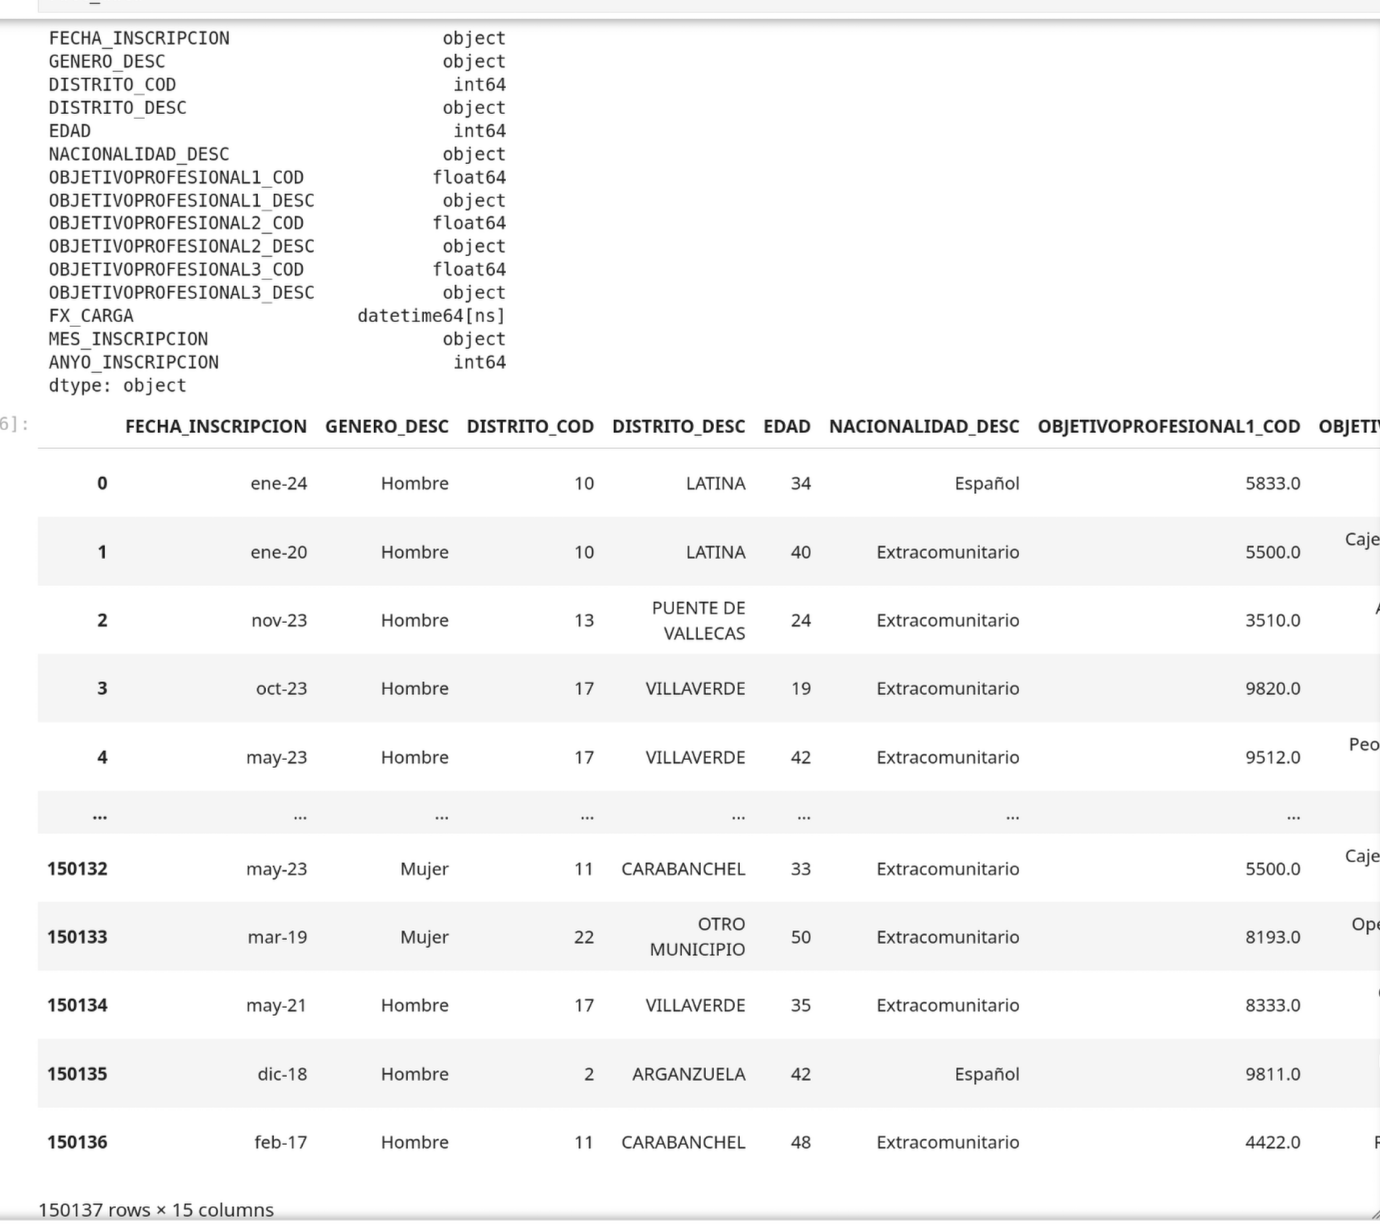

### Comprobaciones automáticas

In [7]:
testing.test_load_dataframe(load_dataframe)
    


size = (150137, 15).....OK
El tipo de la columna FECHA_INSCRIPCION es object....OK
El tipo de la columna GENERO_DESC es object....OK
El tipo de la columna DISTRITO_COD es int64....OK
El tipo de la columna DISTRITO_DESC es object....OK
El tipo de la columna EDAD es int64....OK
El tipo de la columna NACIONALIDAD_DESC es object....OK
El tipo de la columna OBJETIVOPROFESIONAL1_COD es float64....OK
El tipo de la columna OBJETIVOPROFESIONAL1_DESC es object....OK
El tipo de la columna OBJETIVOPROFESIONAL2_COD es float64....OK
El tipo de la columna OBJETIVOPROFESIONAL2_DESC es object....OK
El tipo de la columna OBJETIVOPROFESIONAL3_COD es float64....OK
El tipo de la columna OBJETIVOPROFESIONAL3_DESC es object....OK
El tipo de la columna FX_CARGA es datetime64[ns]....OK
El tipo de la columna MES_INSCRIPCION es object....OK
El tipo de la columna ANYO_INSCRIPCION es int64....OK
OK


In [8]:
testing.test_type_hints_load_dataframe(load_dataframe)

load_dataframe type hints OK


In [9]:
testing.test_docstring(load_dataframe)

docstring OK


In [10]:
testing.test_doctests(load_dataframe, globals())

doctests OK


### Una tabla más reducida

En efecto: no vamos a necesitar las columnas de los objetivos profesionales. Define una función `reduce_cols` que devuelva una tabla reducida con las columnas deseadas.  

In [11]:
def reduce_cols( df: DataFrame) -> DataFrame:
    """
    Reduce el dataframe a las columnas quitando las columnas de los objetivos profesionales.

    Parametros:
    ----------- 
    df : DataFrame. DataFrame con los datos del archivo csv

    Returns:    
    --------
    DataFrame : DataFrame con solo las columnas necesarias para el análisis

    Example:
    --------
    >>> import pandas as pd
    >>> df = load_dataframe('inscritos.csv')
    >>> df_reduced = reduce_cols(df)

    """
    return df[['FECHA_INSCRIPCION', 'GENERO_DESC', 'DISTRITO_COD', 'DISTRITO_DESC', 'EDAD', 'NACIONALIDAD_DESC', 'FX_CARGA', 'MES_INSCRIPCION', 'ANYO_INSCRIPCION']]

In [12]:
# Casilla para pruebas



### Auto-comprobacion

In [13]:
mini = reduce_cols(full_data)
print(mini.dtypes)
mini

FECHA_INSCRIPCION               str
GENERO_DESC                     str
DISTRITO_COD                  int64
DISTRITO_DESC                   str
EDAD                          int64
NACIONALIDAD_DESC               str
FX_CARGA             datetime64[us]
MES_INSCRIPCION                 str
ANYO_INSCRIPCION              int64
dtype: object


,FECHA_INSCRIPCION,GENERO_DESC,DISTRITO_COD,DISTRITO_DESC,EDAD,NACIONALIDAD_DESC,FX_CARGA,MES_INSCRIPCION,ANYO_INSCRIPCION
0,ene-24,Hombre,10,LATINA,34,Español,2025-08-07 00:11:57.897,ene,24
1,ene-20,Hombre,10,LATINA,40,Extracomunitario,2025-08-07 00:11:57.897,ene,20
2,nov-23,Hombre,13,PUENTE DE VALLECAS,24,Extracomunitario,2025-08-07 00:11:57.897,nov,23
3,oct-23,Hombre,17,VILLAVERDE,19,Extracomunitario,2025-08-07 00:11:57.897,oct,23
4,may-23,Hombre,17,VILLAVERDE,42,Extracomunitario,2025-08-07 00:11:57.897,may,23
...,...,...,...,...,...,...,...,...,...
150132,may-23,Mujer,11,CARABANCHEL,33,Extracomunitario,2025-08-07 00:12:50.377,may,23
150133,mar-19,Mujer,22,OTRO MUNICIPIO,50,Extracomunitario,2025-08-07 00:12:50.377,mar,19
150134,may-21,Hombre,17,VILLAVERDE,35,Extracomunitario,2025-08-07 00:12:50.377,may,21
150135,dic-18,Hombre,2,ARGANZUELA,42,Español,2025-08-07 00:12:50.377,dic,18


Salida esperada

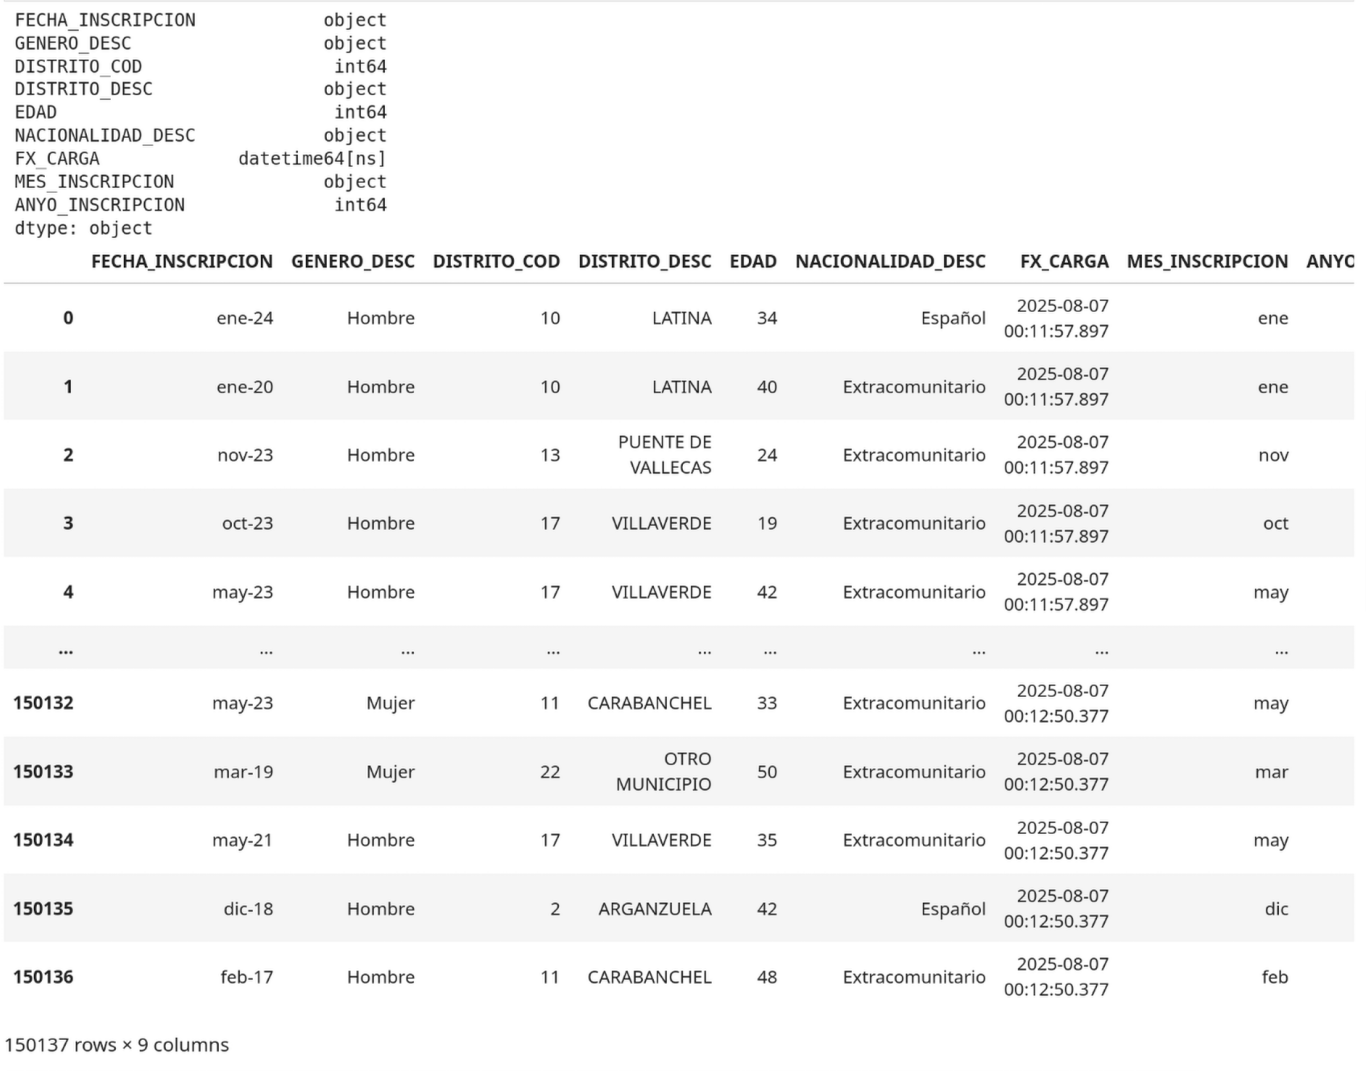

### Comprobaciones automáticas

In [14]:
testing.test_reduce_cols(reduce_cols, load_dataframe)
    

size = (150137, 9).....OK
Columnas...... OK
El tipo de la columna FECHA_INSCRIPCION es object....OK
El tipo de la columna GENERO_DESC es object....OK
El tipo de la columna DISTRITO_COD es int64....OK
El tipo de la columna DISTRITO_DESC es object....OK
El tipo de la columna EDAD es int64....OK
El tipo de la columna NACIONALIDAD_DESC es object....OK
El tipo de la columna FX_CARGA es datetime64[ns]....OK
El tipo de la columna MES_INSCRIPCION es object....OK
El tipo de la columna ANYO_INSCRIPCION es int64....OK


In [15]:
testing.test_type_hints_reduce_cols(reduce_cols)

reduce_cols type hints OK
reduce_cols type hints OK


In [16]:
testing.test_docstring(reduce_cols)

docstring OK


In [17]:
testing.test_doctests(reduce_cols, globals())

doctests OK


### Selección de un año

Define una función `filter_year` que dado un DataFrame nos devuelva las columnas que se correspondan con un determinado año.

In [18]:
def filter_year(df: DataFrame, year: int) -> DataFrame:
    """
    Filtra el dataframe para quedarse solo con los registros del año pasado como argumento.

    Parametros:
    -----------
    df : DataFrame. DataFrame con los datos del archivo csv
    year : int. Año por el que se desea filtrar el dataframe

    Returns:
    --------    
    DataFrame : DataFrame filtrado por el año pasado como argumento

    Example:
    --------
    >>> import pandas as pd
    >>> df = load_dataframe('inscritos.csv')
    >>> df_filtered = filter_year(df, 2022)
    """
    return df[df['ANYO_INSCRIPCION'] + 2000 == year]


In [19]:
# Casilla para hacer pruebas


### Auto-comprobación

In [20]:
year_2022 = filter_year(mini, 2022)
year_2022

,FECHA_INSCRIPCION,GENERO_DESC,DISTRITO_COD,DISTRITO_DESC,EDAD,NACIONALIDAD_DESC,FX_CARGA,MES_INSCRIPCION,ANYO_INSCRIPCION
9,ago-22,Hombre,3,RETIRO,57,Extracomunitario,2025-08-07 00:11:57.897,ago,22
14,jun-22,Hombre,22,OTRO MUNICIPIO,21,Extracomunitario,2025-08-07 00:11:57.897,jun,22
18,feb-22,Hombre,13,PUENTE DE VALLECAS,47,Español,2025-08-07 00:11:57.897,feb,22
22,ago-22,Mujer,11,CARABANCHEL,27,Español,2025-08-07 00:11:57.897,ago,22
27,jul-22,Hombre,6,TETUÁN,35,Extracomunitario,2025-08-07 00:11:57.897,jul,22
...,...,...,...,...,...,...,...,...,...
150072,dic-22,Mujer,20,SAN BLAS - CANILLEJAS,38,Español,2025-08-07 00:12:50.377,dic,22
150090,sep-22,Hombre,21,BARAJAS,20,Extracomunitario,2025-08-07 00:12:50.377,sep,22
150113,abr-22,Hombre,13,PUENTE DE VALLECAS,25,Extracomunitario,2025-08-07 00:12:50.377,abr,22
150121,mar-22,Hombre,10,LATINA,25,Comunitario,2025-08-07 00:12:50.377,mar,22


Salida esperada

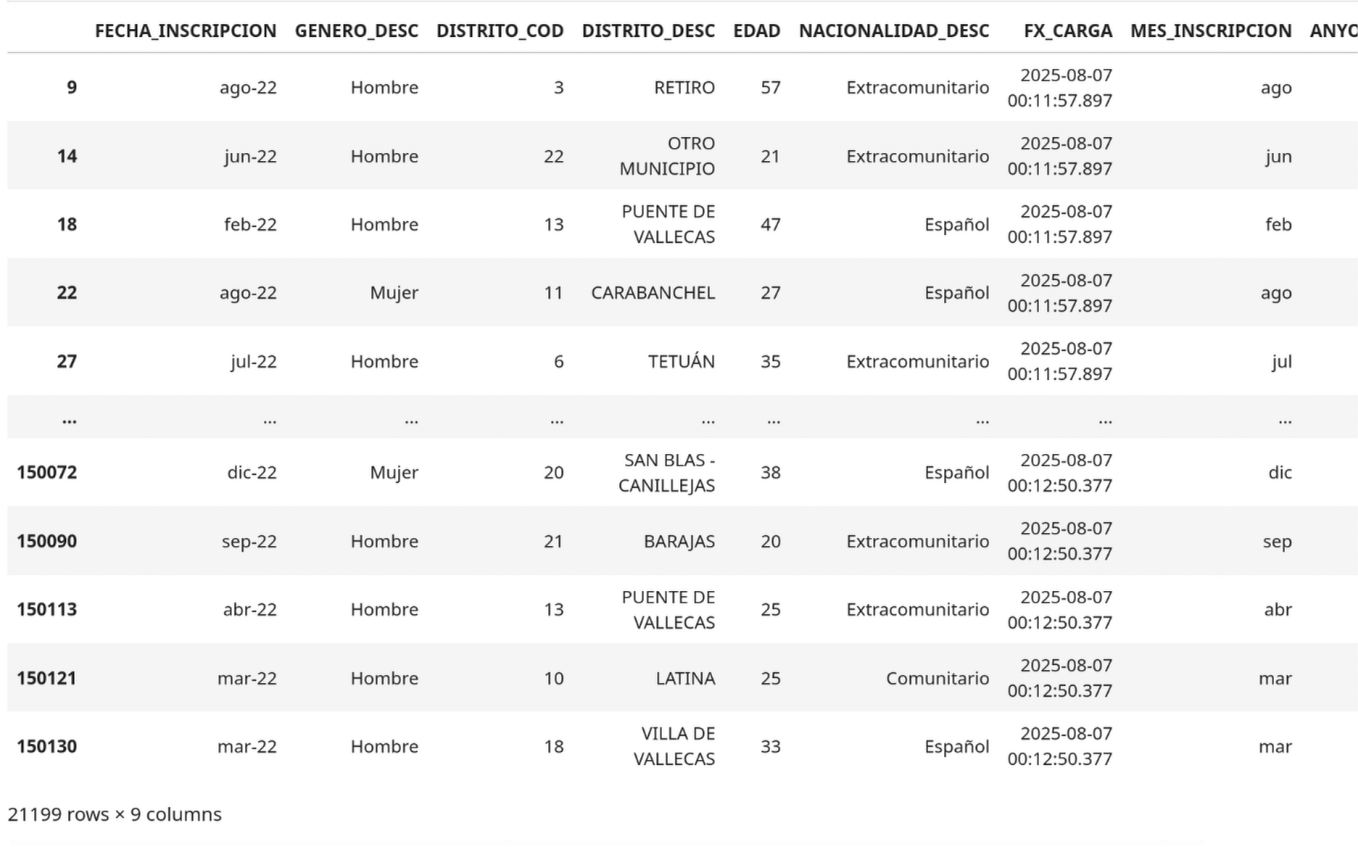

### Comprobaciones automáticas

In [21]:
testing.test_filter_year(filter_year, load_dataframe)



OK


In [22]:
testing.test_type_hints_filter_year(filter_year)

filter_year type hints OK
filter_year type hints OK


In [23]:
testing.test_docstring(filter_year)

docstring OK


In [24]:
testing.test_doctests(filter_year, globals())

doctests OK


## Tanteo por meses

Realiza una función `by_month` que dado el DataFrame de un año,  obtenga una lista ordenada de tuplas de la forma `(mes, total)` tal que el total es el número de personas que se han inscrito en ese mes. La función deberá hacer un agrupamiento en el DataFrame y transformar el resultado para que finalmente devuelva algo del tipo `list[tuple[str, int]]`. La lista deberá estar ordenada con respecto al mes.

In [ ]:
def by_month(df: DataFrame) -> list[tuple[str, int]]:
    """
    Agrupa por mes y devuelve una lista de tuplas ordenada cronológicamente.

    Parametros:
    -----------
    df : DataFrame. DataFrame con los datos del archivo csv

    Returns:
    --------
    list[tuple[str, int]] : Lista de tuplas con el mes y el número de inscripciones, ordenada cronológicamente

    Example:
    --------
    >>> import pandas as pd
    >>> df = load_dataframe('inscritos_test_sample.csv')
    >>> df_reduced = reduce_cols(df)
    >>> df_filtered = filter_year(df_reduced, 2022)
    >>> bym = by_month(df_filtered)
    >>> bym
    [('ene', 11), ('feb', 21), ('mar', 13), ('abr', 16), ('may', 19), ('jun', 24), ('jul', 12), ('ago', 19), ('sep', 25), ('oct', 19), ('nov', 20), ('dic', 18)]
    """
    # 1. El diccionario de meses
    orden_meses = {'ene': 0, 'feb': 1, 'mar': 2, 'abr': 3, 'may': 4, 'jun': 5,
                   'jul': 6, 'ago': 7, 'sep': 8, 'oct': 9, 'nov': 10, 'dic': 11}

    # 2. Agrupamos y contamos (esto nos da una Series con los meses encontrados)
    resumen = df.groupby('MES_INSCRIPCION').size()

    # 3. Convertimos a lista de tuplas 
    lista_tuplas = list(resumen.items())

    # 4. Ordenamos la lista usando el diccionario como "llave" de ordenación
    # Usamos orden_meses.get(x[0]) para que mire el nombre del mes en el diccionario
    lista_tuplas.sort(key=lambda x: orden_meses.get(x[0]))

    return lista_tuplas

In [26]:
# Casilla para hacer pruebas
by_month(year_2022)

[('ene', 804),
 ('feb', 2129),
 ('mar', 2257),
 ('abr', 1677),
 ('may', 2014),
 ('jun', 1727),
 ('jul', 1338),
 ('ago', 1511),
 ('sep', 1711),
 ('oct', 1939),
 ('nov', 2292),
 ('dic', 1800)]

### Auto-comprobación

In [27]:
bym = by_month(year_2022)
bym

[('ene', 804),
 ('feb', 2129),
 ('mar', 2257),
 ('abr', 1677),
 ('may', 2014),
 ('jun', 1727),
 ('jul', 1338),
 ('ago', 1511),
 ('sep', 1711),
 ('oct', 1939),
 ('nov', 2292),
 ('dic', 1800)]

Salida esperada

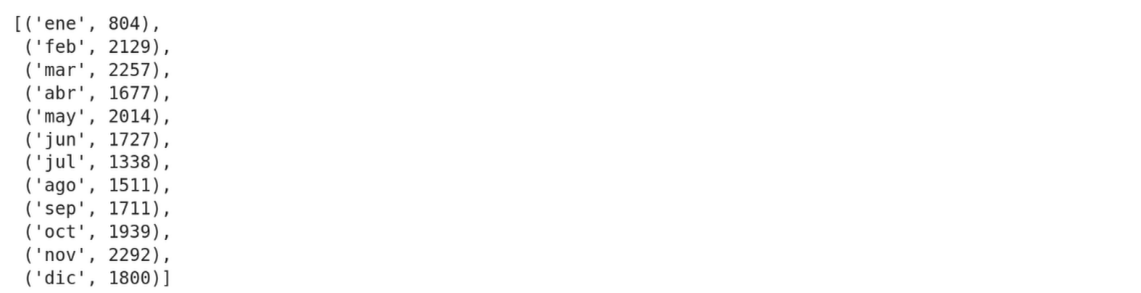

### Comprobaciones automáticas

In [28]:
testing.test_by_month(by_month, filter_year, load_dataframe)

OK


In [29]:
testing.test_type_hints_by_month(by_month)

by_month type hints OK


In [30]:
testing.test_docstring(by_month)

docstring OK


In [31]:
testing.test_doctests(by_month, globals())


doctests OK


# Gráficas

Finalmente, vamos a realizar un par de gráficos. En primer lugar, queremos sacar el número de personas inscritas por cada mes. Realiza una función `show_by_month` que reciba como dato de entrada un fichero de datos csv y un año y que  realice gráfico de barras del número de desempleados por meses de ese año


In [ ]:
def show_by_month(archivo: str, year: int) -> None:
    """
    Genera un gráfico de barras del número de inscritos por mes para un año dado.

    Parametros:
    -----------
    archivo : str. Ruta al archivo csv que se desea cargar.
    year : int. Año por el que se desea filtrar el dataframe

    Returns:
    --------
    None. Muestra un gráfico de barras con el número de inscritos por mes para el año dado.
    """
    df = load_dataframe(archivo)
    df_reduced = reduce_cols(df)
    df_filtered = filter_year(df_reduced, year)
    bym = by_month(df_filtered)

    # Creamos la figura y los ejes de forma explícita
    fig, ax = plt.subplots(figsize=(10, 6))

    months = [f[0] for f in bym]
    peticiones = [f[1] for f in bym]

    # Dibujamos las barras
    ax.bar(months, peticiones)

    # AJUSTE EJE X: Para que salgan rotadas
    ax.set_xticklabels(months, rotation=45) 

    # AJUSTE CUADRÍCULA: Rayas discontinuas perpendiculares al eje Y
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)

    ax.set_ylabel('Num peticiones')
    ax.set_xlabel(f'Meses referidos a {year}')
    ax.set_title('Peticiones de empleo')

    plt.show()

In [33]:
# Casilla para pruebas


### Auto-comprobación

/var/folders/ww/09f7z5gd0h98gl8t0hpy8mv00000gn/T/ipykernel_1119/1795753396.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(months, rotation=45)


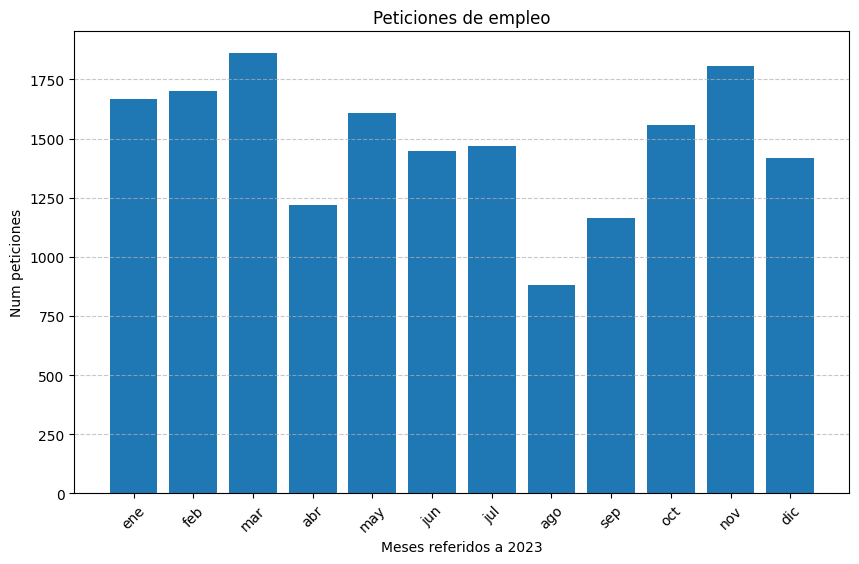

In [34]:
show_by_month('inscritos.csv', 2023)

Salida esperada

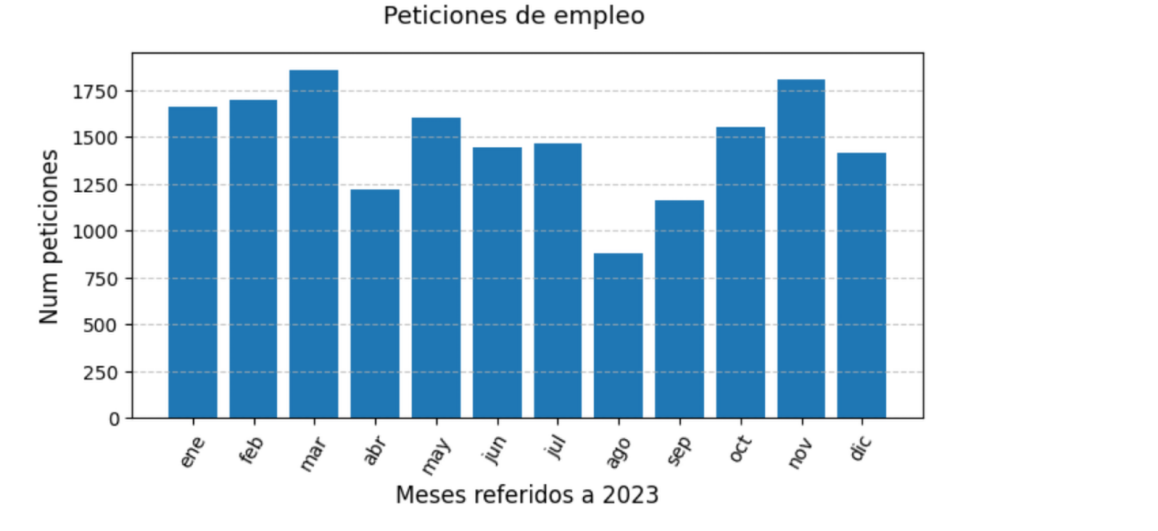

## Inscritos por distritos en un año

Realiza una función `show_district` que genere un gráfico de tarta del número de desempleados por distrito en un determinado año. Al igual que en el caso anterior,
la función recibe como parámetros el nombre de un fichero con los datos y el año. Si lo haces verás que el distrito que más se repite es 'OTRO MUNICIPIO'. Debes filtrar los datos, de forma
que solo se consideren los distritos de Madrid.

In [ ]:
def show_district(archivo: str, year: int) -> None:
    """
    Genera un gráfico de tarta del número de inscritos por distrito para un año
    específico, excluyendo 'OTRO MUNICIPIO'.

    Parametros:
    -----------
    archivo : str. Ruta al archivo csv.
    year : int. Año por el que se desea filtrar.

    Returns:
    --------
    None. Muestra el gráfico por pantalla.
    """
    # 1. Carga y filtrado inicial
    df = load_dataframe(archivo)
    df_reduced = reduce_cols(df)
    df_filtered = filter_year(df_reduced, year)

    # 2. Filtramos para considerar solo distritos de Madrid
    # Eliminamos 'OTRO MUNICIPIO' según pide el enunciado
    df_madrid = df_filtered[df_filtered['DISTRITO_DESC'] != 'OTRO MUNICIPIO']

    # 3. Agrupamos por distrito, contamos y odenamos
    distritos_counts = df_madrid.groupby('DISTRITO_DESC').size().sort_values(ascending=False)
    
    # 4. Preparamos datos para el gráfico
    labels = distritos_counts.index
    sizes = distritos_counts.values

    # 5. Generamos el gráfico de tarta
    explode = [0.1] + [0] * (len(sizes) - 1)  # Creamos esta lista para que salga el primer distrito y así destacar el distrito con más peticiones
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%', startangle=0)
    ax.set_title('Peticiones empleo por distrito')
    ax.set_xlabel(f'Datos referidos a {year}')
    plt.show()

    
   
    
  

In [36]:
# Casilla para pruebas



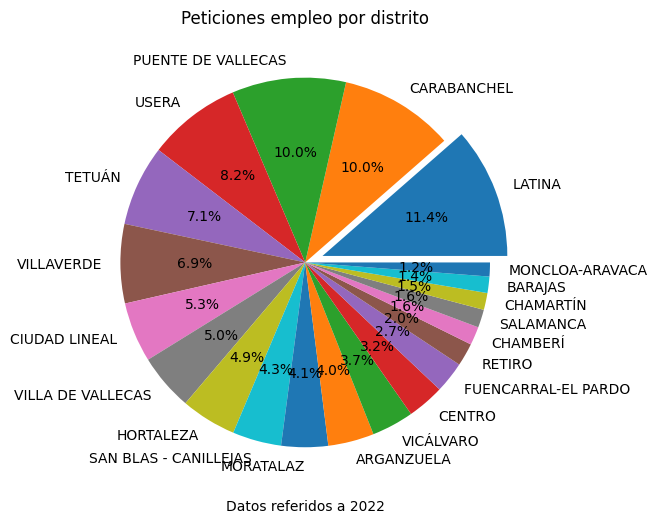

In [37]:
show_district('inscritos.csv', 2022)

Salida esperada

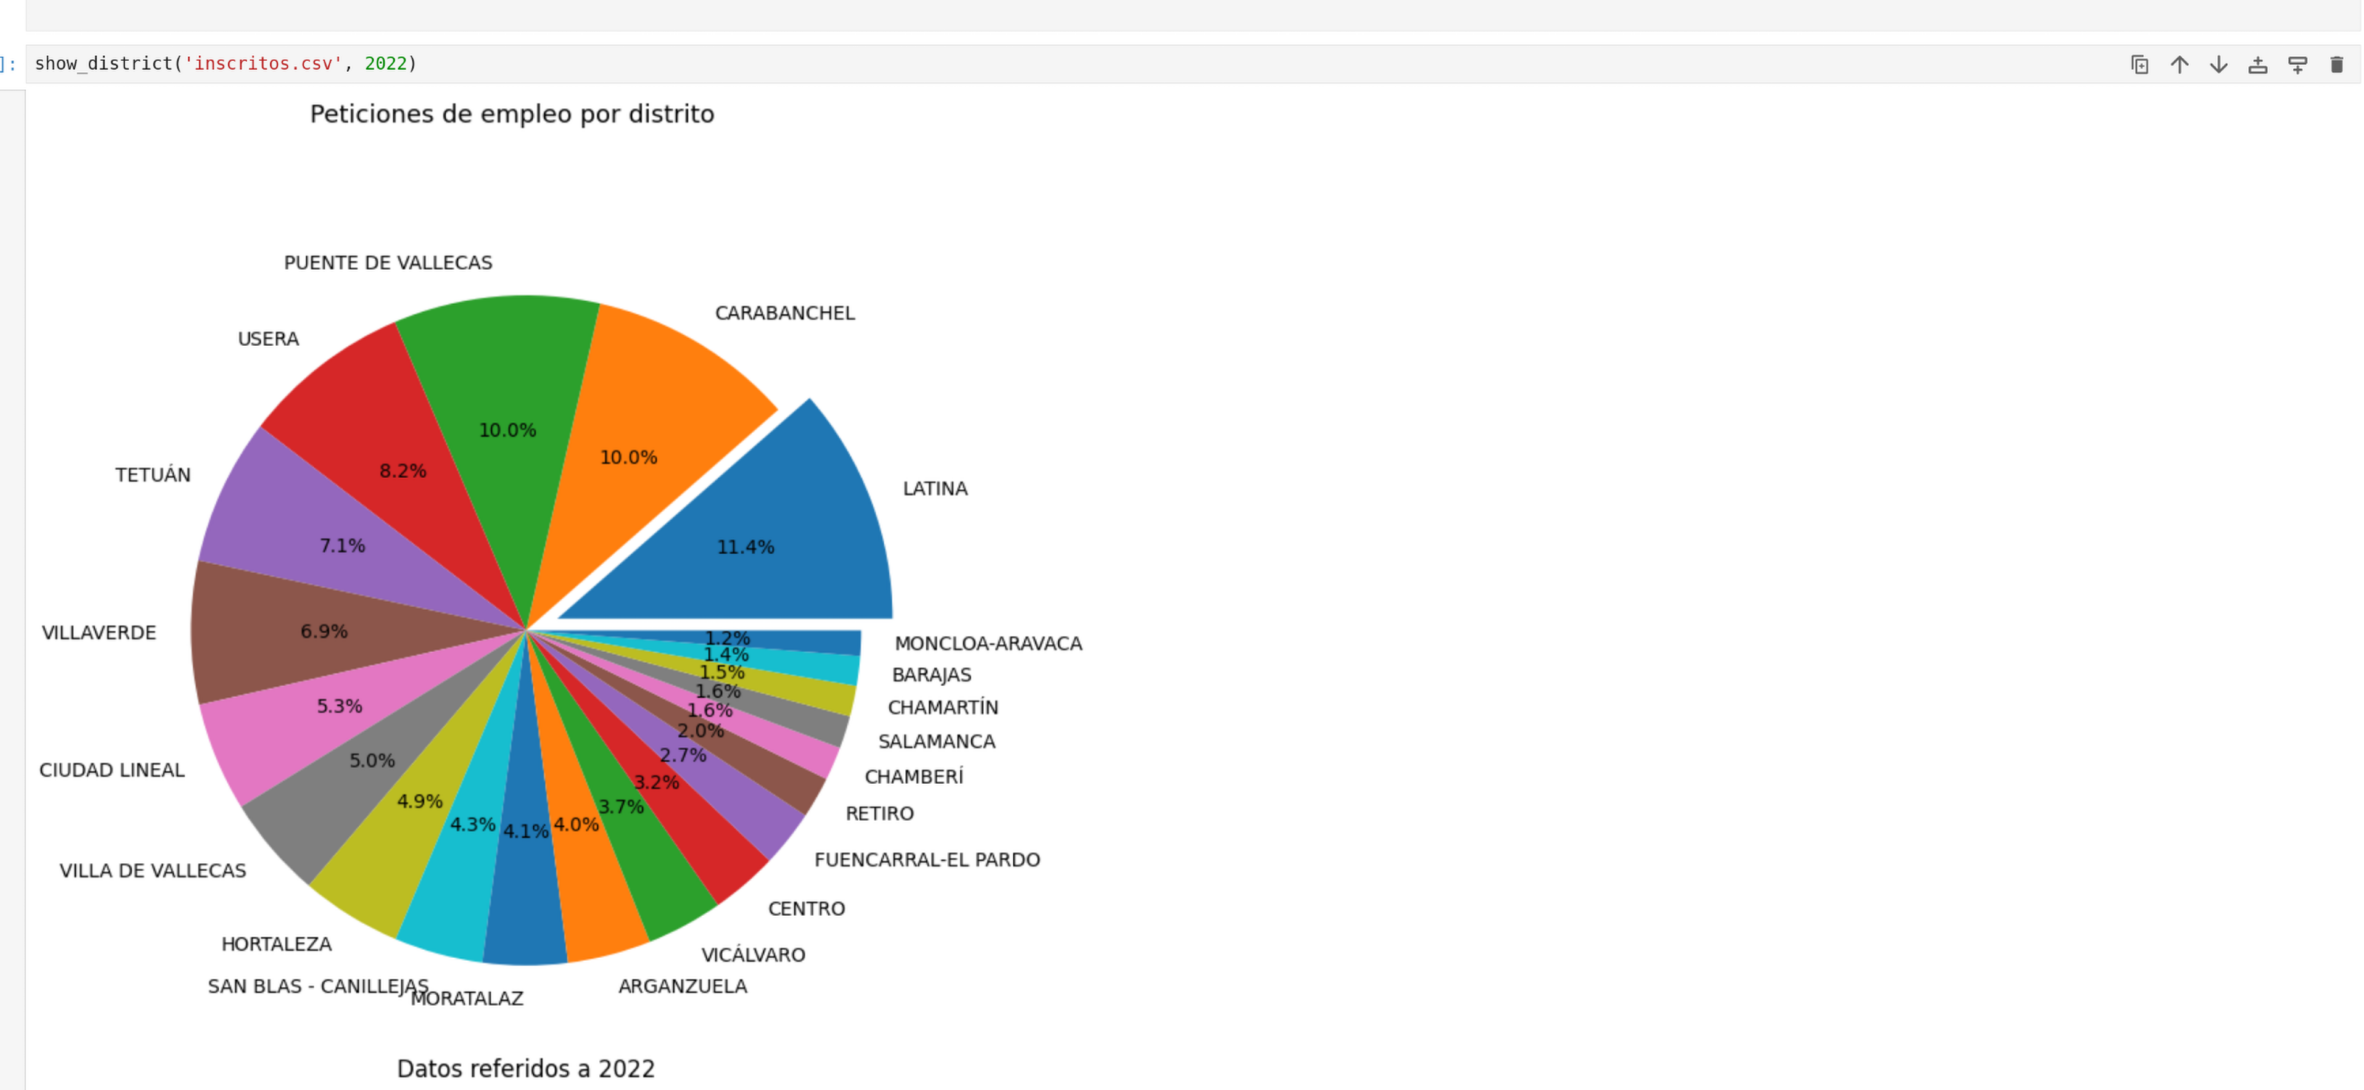